# 6 &middot; Why Line Search Matters

A Newton *direction* $-H^{-1}\nabla E$ points the right way, but the *step length* still matters: too
large a step overshoots, inverts elements, and the energy **explodes** instead of decreasing.
**Backtracking line search** starts from the full Newton step and shrinks it until the energy decreases
enough (the Armijo condition). We drag a stiff beam's right edge slowly out and back, taking a few Newton
iterations per frame, once with a fixed, too-large step and once with line search.

Imports, and every tunable parameter of this notebook.

In [1]:
%matplotlib inline
import os
import numpy as np
import scipy as sp
import matplotlib.pyplot as plt
from matplotlib.colors import TwoSlopeNorm
import igl
import simkit
import utils

NOTEBOOK = "006_line_search"                                      # this file's name
RESULTS_DIR = simkit.filesystem.notebook_results_path(NOTEBOOK)   # results/006_line_search/
MEDIA_DIR = "media"                                               # tracked copies for the website
# mesh: a thick beam
NX, NY = 16, 7                  # grid vertices along x and y
WIDTH, HEIGHT = 2.0, 0.6        # beam size
# material: stiff and nearly incompressible
YM = 50.0                       # Young's modulus
PR = 0.49                       # Poisson ratio (nearly incompressible)
MATERIAL = "macklin-mueller-neo-hookean"   # Neo-Hookean elastic energy
K_PIN = 1e6                     # penalty stiffness of the pin and of the handle
# handle motion
HANDLE_TRAVEL = 1.0             # how far the handle slides to the right
N_RAMP = 22                     # frames out (and as many back)
# Newton
ITERS_PER_FRAME = 2             # Newton iterations per handle position
FIXED_STEP = 2.0                # the deliberately too-large fixed step t (in Newton steps)
ARMIJO_C = 0.01                 # Armijo sufficient-decrease constant c
BACKTRACK_BETA = 0.5            # step shrink factor per backtracking trial
DIVERGE = 1e3                   # max |x| above this counts as blown up
# validation
FD_STEP = 1e-5                  # central-difference step of the gradient check
FD_NOISE = 0.01                 # random perturbation of the rest state for that check
SEED = 0                        # random seed of that perturbation
T_MAX_PROFILE = 2.5             # largest step t sampled along one Newton direction
N_PROFILE = 101                 # number of samples along it
# video
FPS_FIXED = 12                  # frame rate of the (short) exploding run
FPS_LS = 20                     # frame rate of the line-search run

## A thick, stiff beam and its handle path

A thick $2 \times 0.6$ grid from libigl: the left edge is pinned (blue squares) and the whole right edge
is the handle (orange). The handle slides `HANDLE_TRAVEL` to the right over `N_RAMP` frames and then
back; the figure shows the rest mesh and that path.

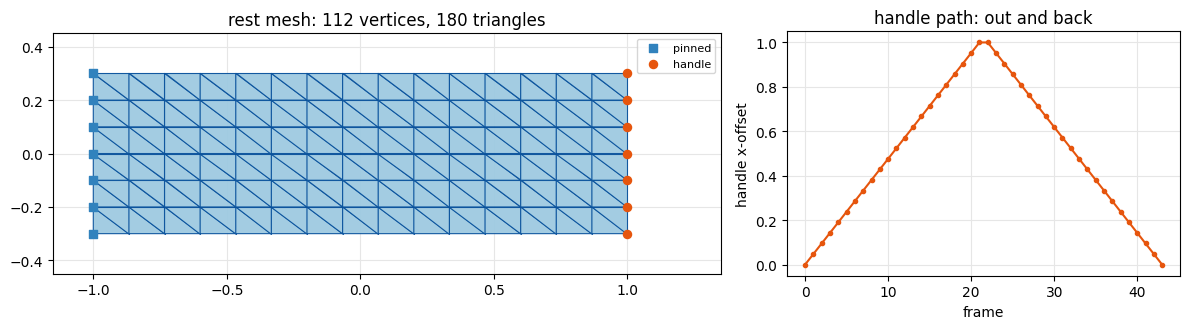

In [2]:
V, T = igl.triangulated_grid(NX, NY)                     # unit square, NX x NY vertices
X = (V - 0.5) * np.array([WIDTH, HEIGHT])                # centered WIDTH x HEIGHT beam
n, dim = X.shape
pin_idx = np.where(X[:, 0] <= X[:, 0].min() + 1e-6)[0]      # left edge
handle_idx = np.where(X[:, 0] >= X[:, 0].max() - 1e-6)[0]   # right edge

ramp = np.concatenate([np.linspace(0, 1, N_RAMP), np.linspace(1, 0, N_RAMP)])   # right, then back
HANDLE_OFFSETS = ramp[:, None] * np.array([HANDLE_TRAVEL, 0.0])                   # (frames, 2)

fig, (ax_mesh, ax_ramp) = plt.subplots(1, 2, figsize=(12, 3.4), gridspec_kw={"width_ratios": [1.7, 1]})
utils.plot_mesh(ax_mesh, X, T, pins=pin_idx, handles=handle_idx,
                title=f"rest mesh: {n} vertices, {len(T)} triangles", lims=((-1.15, 1.35), (-0.45, 0.45)))
ax_ramp.plot(HANDLE_OFFSETS[:, 0], "o-", ms=3, color=utils.HANDLE_C)
ax_ramp.set(xlabel="frame", ylabel="handle x-offset", title="handle path: out and back")
ax_ramp.grid(True, color="0.9")
fig.tight_layout()
simkit.filesystem.save_figure(fig, os.path.join(RESULTS_DIR, "mesh.png"),
                              copy_to=os.path.join(MEDIA_DIR, "006_mesh.png"))
plt.show()

## The beam system

`beam_system` returns the energy, gradient and Hessian of Neo-Hookean elasticity plus a soft spring for
the pin and one for the handle, one term per line. The beam is thick (bending stores more energy) and
nearly incompressible ($\nu = 0.49$ resists volume change), so an over-eager step bites fast. The
Armijo test compares the energy with the gradient's prediction, so the cell ends by checking
`gradient_func` against central differences (`simkit.gradient_cfd`); the relative error should be tiny.

In [3]:
J = simkit.deformation_jacobian(X, T)
vol = simkit.volume(X, T)
mu, lam = simkit.ympr_to_lame(YM, PR)
mu = np.full((len(T), 1), mu)
lam = np.full((len(T), 1), lam)
Q_pin, b_pin = simkit.dirichlet_penalty(pin_idx, X[pin_idx], n, K_PIN)      # the pin never moves

def beam_system(handle_targets):
    """Neo-Hookean beam + soft pin (left edge) + soft handle (right edge) pulled to handle_targets."""
    Q_handle, b_handle = simkit.dirichlet_penalty(handle_idx, handle_targets, n, K_PIN)

    def energy_func(x):
        E_elastic = simkit.energies.elastic_energy_x(x.reshape(n, dim), J, mu, lam, vol, MATERIAL)
        E_pin = simkit.energies.quadratic_energy(x, Q_pin, b_pin)
        E_handle = simkit.energies.quadratic_energy(x, Q_handle, b_handle)
        E_total = E_elastic + E_pin + E_handle
        return E_total

    def gradient_func(x):
        g_elastic = simkit.energies.elastic_gradient_x(x.reshape(n, dim), J, mu, lam, vol, MATERIAL)
        g_pin = simkit.energies.quadratic_gradient(x, Q_pin, b_pin)
        g_handle = simkit.energies.quadratic_gradient(x, Q_handle, b_handle)
        g_total = g_elastic + g_pin + g_handle
        return g_total

    def hessian_func(x):
        H_elastic = simkit.energies.elastic_hessian_x(x.reshape(n, dim), J, mu, lam, vol, MATERIAL, psd=True)
        H_pin = simkit.energies.quadratic_hessian(Q_pin)
        H_handle = simkit.energies.quadratic_hessian(Q_handle)
        H_total = H_elastic + H_pin + H_handle
        return H_total

    return energy_func, gradient_func, hessian_func

# gradient check at a randomly perturbed rest state, with the handle at its farthest target
energy_func, gradient_func, _ = beam_system(X[handle_idx] + HANDLE_OFFSETS[N_RAMP - 1])
x_test = X.reshape(-1) + FD_NOISE * np.random.default_rng(SEED).standard_normal(n * dim)
g_fd = simkit.gradient_cfd(lambda y: np.array(energy_func(y.reshape(-1, 1))), x_test, FD_STEP)
g_an = gradient_func(x_test.reshape(-1, 1)).ravel()
print(f"gradient check: relative error {np.linalg.norm(g_an - g_fd) / np.linalg.norm(g_an):.1e}")

gradient check: relative error 2.5e-10


## The quasi-static driver

At each handle position we take `ITERS_PER_FRAME` Newton iterations: solve $H\,\Delta x = -g$, then step
$x \leftarrow x + t\,\Delta x$. The two runs differ only in $t$: a fixed `FIXED_STEP` $= 2$, or the step
chosen by `simkit.backtracking_line_search`, which tries $t = 1$ and multiplies it by `BACKTRACK_BETA`
until the Armijo condition holds (with line search this is one iteration of
`simkit.solvers.newton_solver`). The printout says when the fixed-step run blows up and how often the
line search kept the full Newton step.

$$E(x + t\,\Delta x) \;\le\; E(x) + c\,t\,g^\top \Delta x$$

In [4]:
def drive(use_line_search):
    """Sweep the handle along HANDLE_OFFSETS; return each frame's final state and every step t taken."""
    x = X.reshape(-1, 1).copy()
    states, steps = [], []
    for offset in HANDLE_OFFSETS:
        energy_func, gradient_func, hessian_func = beam_system(X[handle_idx] + offset)
        for _ in range(ITERS_PER_FRAME):
            g = gradient_func(x)
            H = hessian_func(x)
            dx = sp.sparse.linalg.spsolve(H.tocsc(), -g).reshape(-1, 1)          # Newton direction
            if use_line_search:
                t = simkit.backtracking_line_search(energy_func, x, g, dx,
                                                    alpha=ARMIJO_C, beta=BACKTRACK_BETA)[0]
            else:
                t = FIXED_STEP
            x = x + t * dx
            steps.append(t)
        states.append(x.reshape(n, dim).copy())
        if not np.all(np.isfinite(x)) or np.abs(x).max() > DIVERGE:
            break                                                                 # blew up
    return states, np.array(steps)

fixed_states, fixed_steps = drive(use_line_search=False)
ls_states, ls_steps = drive(use_line_search=True)
print(f"fixed step t = {FIXED_STEP:g} (no line search): blew up at frame {len(fixed_states) - 1} "
      f"of {len(HANDLE_OFFSETS)}")
print(f"line search: completed all {len(ls_states)} frames; kept the full step t = 1 in "
      f"{np.sum(ls_steps == 1.0)} of {len(ls_steps)} iterations")

fixed step t = 2 (no line search): blew up at frame 9 of 44
line search: completed all 44 frames; kept the full step t = 1 in 88 of 88 iterations


## Without line search: the solver explodes

With $t = 2$ each step lands as far past the minimum as it started before it, so the error is mirrored,
never removed. It accumulates as the handle moves until elements invert (frame 8) and the next step flings
the mesh off screen (frame 9).

In [5]:
lims = ((-1.3, 2.2), (-1.6, 1.6))
fig, anim = utils.animate_mesh(fixed_states, T, lims=lims,
                               title="Fixed step, NO line search  ->  explodes", pin_pts=X[pin_idx],
                               handle_traj=[s[handle_idx] for s in fixed_states], fps=FPS_FIXED)
video = simkit.filesystem.save_animation(anim, os.path.join(RESULTS_DIR, "no_line_search.mp4"), fps=FPS_FIXED,
                                         copy_to=os.path.join(MEDIA_DIR, "006_no_line_search.mp4"))
plt.close(fig)
utils.embed_video(video)

## With line search: smooth and stable

The same sweep with backtracking line search follows the handle out and back without a hitch.

In [6]:
fig, anim = utils.animate_mesh(ls_states, T, lims=lims,
                               title="Backtracking line search  ->  stable", pin_pts=X[pin_idx],
                               handle_traj=[s[handle_idx] for s in ls_states], fps=FPS_LS)
video = simkit.filesystem.save_animation(anim, os.path.join(RESULTS_DIR, "line_search.mp4"), fps=FPS_LS,
                                         copy_to=os.path.join(MEDIA_DIR, "006_line_search.mp4"))
plt.close(fig)
utils.embed_video(video)

## Why it fails: per-frame diagnostics

For each frame's final state we plot the gradient norm $\|\nabla E\|$ (distance from equilibrium) and
the smallest $\det F$ over all triangles (below zero means inverted). The printout compares the two
runs' energies at the blow-up frame; they are negative because the soft springs drop their constant
$\tfrac12 K\|y\|^2$, so only differences matter.

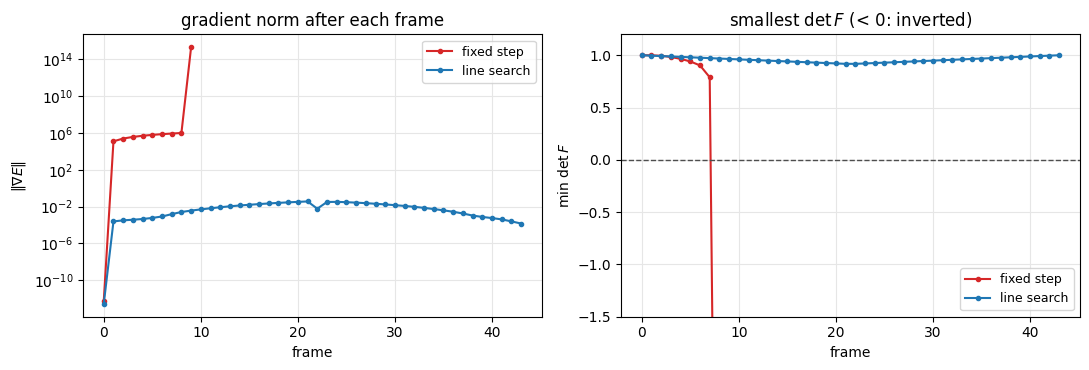

frame 9: energy 1.07e+19 (fixed step) vs -1.09e+07 (line search)


In [7]:
def frame_diagnostics(states):
    """Energy, gradient norm and smallest det F of each frame's final state."""
    E, g_norm, det_min = [], [], []
    for state, offset in zip(states, HANDLE_OFFSETS):
        energy_func, gradient_func, _ = beam_system(X[handle_idx] + offset)
        x = state.reshape(-1, 1)
        E.append(energy_func(x))
        g_norm.append(np.linalg.norm(gradient_func(x)))
        det_min.append(np.linalg.det(simkit.deformation_gradient(X, T, state)).min())
    return np.array(E), np.array(g_norm), np.array(det_min)

E_fixed, g_fixed, det_fixed = frame_diagnostics(fixed_states)
E_ls, g_ls, det_ls = frame_diagnostics(ls_states)
runs = {"fixed step": (g_fixed, det_fixed, "#d62728"), "line search": (g_ls, det_ls, "#1f77b4")}

fig, (ax_g, ax_d) = plt.subplots(1, 2, figsize=(11, 3.8))
for name, (g_norm, det_min, color) in runs.items():
    ax_g.semilogy(g_norm, "o-", ms=3, color=color, label=name)
    ax_d.plot(det_min, "o-", ms=3, color=color, label=name)
ax_g.set(xlabel="frame", ylabel=r"$\|\nabla E\|$", title="gradient norm after each frame")
ax_d.axhline(0.0, color="0.3", lw=1, ls="--")
ax_d.set(xlabel="frame", ylabel=r"min $\det F$", title=r"smallest $\det F$ (< 0: inverted)", ylim=(-1.5, 1.2))
for ax in (ax_g, ax_d):
    ax.grid(True, color="0.9")
    ax.legend(fontsize=9)
fig.tight_layout()
simkit.filesystem.save_figure(fig, os.path.join(RESULTS_DIR, "diagnostics.png"),
                              copy_to=os.path.join(MEDIA_DIR, "006_diagnostics.png"))
plt.show()
k_last = len(fixed_states) - 1
print(f"frame {k_last}: energy {E_fixed[k_last]:.2e} (fixed step) vs {E_ls[k_last]:.2e} (line search)")

The fixed step's gradient norm sits more than eight orders of magnitude above the line-search run and
grows with every frame, and its smallest $\det F$ drops below zero at frame 8, one frame before the
blow-up. The line-search run stays near equilibrium with $\det F \ge 0.9$ throughout.

## Inverted elements, triangle by triangle

$\det F$ per triangle at the first frame where the fixed-step run has inverted elements, next to the
line-search run at the same frame (red: inverted, $\det F < 0$; blue: not inverted).

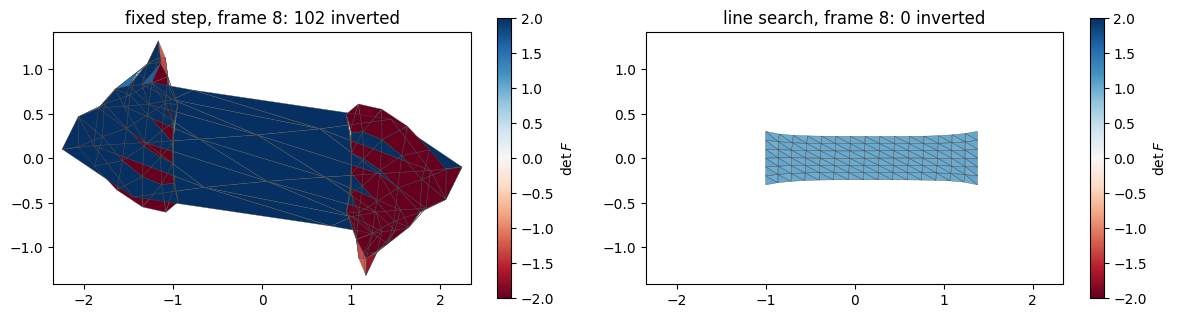

In [8]:
k_bad = int(np.argmax(det_fixed < 0))          # first frame with inverted triangles
fig, axes = plt.subplots(1, 2, figsize=(12, 3.8))
field_lims = utils.auto_limits([fixed_states[k_bad], ls_states[k_bad]], pad=0.1)
for ax, (name, states) in zip(axes, [("fixed step", fixed_states), ("line search", ls_states)]):
    det_F = np.linalg.det(simkit.deformation_gradient(X, T, states[k_bad]))
    utils.plot_scalar_field(ax, states[k_bad], T, det_F, cmap="RdBu", norm=TwoSlopeNorm(vcenter=0.0, vmin=-2.0, vmax=2.0),
                            lims=field_lims, label=r"$\det F$",
                            title=f"{name}, frame {k_bad}: {np.sum(det_F < 0)} inverted")
fig.tight_layout()
simkit.filesystem.save_figure(fig, os.path.join(RESULTS_DIR, "det_F.png"),
                              copy_to=os.path.join(MEDIA_DIR, "006_det_F.png"))
plt.show()

## The energy along one Newton direction

At the start of that frame (the fixed-step run's last state without inverted triangles) we sample
$E(x + t\,\Delta x) - E(x)$ along the Newton direction. It is a near-parabola with its minimum at $t = 1$.
Steps in the green band pass the Armijo test (curve below the dashed line); $t = 2$ lands back at the
starting energy, outside it, and the right panel shows it squeezing triangles almost flat. The star is
where backtracking would end if it started from $t = 2$.

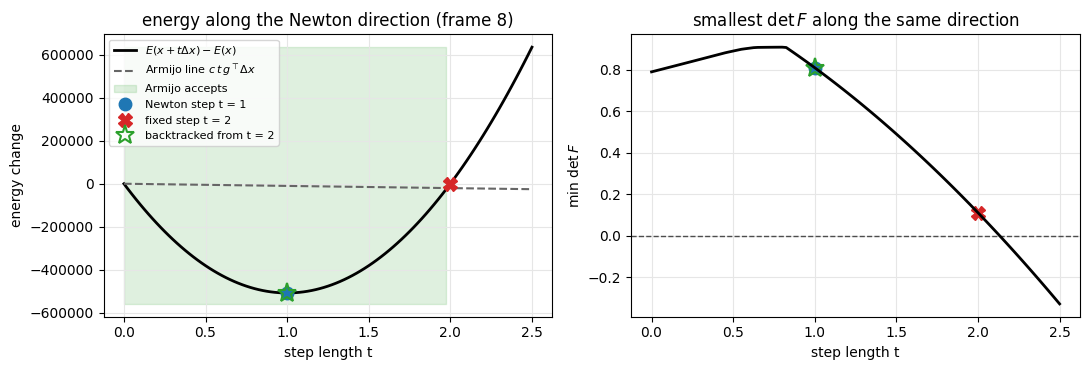

E(x + 2 dx) - E(x) = 51.9  (Armijo needs <= -2.03e+04);  backtracking accepts t = 1


In [9]:
x0 = fixed_states[k_bad - 1].reshape(-1, 1)
energy_func, gradient_func, hessian_func = beam_system(X[handle_idx] + HANDLE_OFFSETS[k_bad])
g = gradient_func(x0)
dx = sp.sparse.linalg.spsolve(hessian_func(x0).tocsc(), -g).reshape(-1, 1)
ts = np.linspace(0.0, T_MAX_PROFILE, N_PROFILE)
dE = np.array([energy_func(x0 + t * dx) for t in ts]) - energy_func(x0)
armijo = ARMIJO_C * ts * (g.T @ dx).item()
det_min_t = np.array([np.linalg.det(simkit.deformation_gradient(X, T, (x0 + t * dx).reshape(n, dim))).min()
                      for t in ts])
t_back = FIXED_STEP * simkit.backtracking_line_search(energy_func, x0, g, FIXED_STEP * dx,
                                                      alpha=ARMIJO_C, beta=BACKTRACK_BETA)[0]

fig, (ax_e, ax_d) = plt.subplots(1, 2, figsize=(11, 3.8))
ax_e.plot(ts, dE, color="k", lw=2, label=r"$E(x+t\Delta x)-E(x)$")
ax_e.plot(ts, armijo, "--", color="0.4", label=r"Armijo line $c\,t\,g^\top\Delta x$")
ax_e.fill_between(ts, dE.min() * 1.1, dE.max(), where=dE <= armijo, color="#2ca02c", alpha=0.15,
                  label="Armijo accepts")
for ax, ys in ((ax_e, dE), (ax_d, det_min_t)):
    ax.plot([1.0], [np.interp(1.0, ts, ys)], "o", color="#1f77b4", ms=9, label="Newton step t = 1")
    ax.plot([FIXED_STEP], [np.interp(FIXED_STEP, ts, ys)], "X", color="#d62728", ms=10,
            label=f"fixed step t = {FIXED_STEP:g}")
    ax.plot([t_back], [np.interp(t_back, ts, ys)], "*", color="#2ca02c", ms=14, mfc="none", mew=1.5,
            label=f"backtracked from t = {FIXED_STEP:g}")
    ax.set_xlabel("step length t")
    ax.grid(True, color="0.9")
ax_e.set(title=f"energy along the Newton direction (frame {k_bad})", ylabel="energy change")
ax_d.axhline(0.0, color="0.3", lw=1, ls="--")
ax_d.plot(ts, det_min_t, color="k", lw=2)
ax_d.set(title=r"smallest $\det F$ along the same direction", ylabel=r"min $\det F$")
ax_e.legend(fontsize=8, loc="upper left")
fig.tight_layout()
simkit.filesystem.save_figure(fig, os.path.join(RESULTS_DIR, "energy_along_step.png"),
                              copy_to=os.path.join(MEDIA_DIR, "006_energy_along_step.png"))
plt.show()
print(f"E(x + {FIXED_STEP:g} dx) - E(x) = {np.interp(FIXED_STEP, ts, dE):.3g}  "
      f"(Armijo needs <= {np.interp(FIXED_STEP, ts, armijo):.3g});  backtracking accepts t = {t_back:g}")

### Takeaways
* A good Newton *direction* isn't enough: an unchecked **step length** can diverge (here $t = 2$ mirrors
  the error instead of removing it, until triangles invert).
* **Backtracking line search** shrinks the step until the energy decreases enough (Armijo).
* Cheap insurance: here it kept the full Newton step every time, so it cost two energy evaluations per
  iteration and bought a solver that won't blow up.